In [1]:
import networkx as nx
import random

def heuristika1(G):
    G = G.copy()
    S = [0] * G.number_of_nodes()

    while G.number_of_nodes() > 0:
        u = random.choice(list(G.nodes))
        susjedi = list(G.neighbors(u))

        S[u] = 3

        for v in susjedi:
            S[v] = 0

        G.remove_nodes_from(susjedi)
        G.remove_node(u)

        if G.number_of_nodes() == 1:
            preostali = next(iter(G.nodes))
            S[preostali] = 2
            G.remove_node(preostali)

    return S
G = nx.Graph()
G.add_nodes_from([i for i in range(7)])
for i in range (7):
    G.add_edge(i, (i + 1)%7)
H = nx.path_graph(50)
print(H.nodes)
X = nx.cycle_graph(39)
print(heuristika1(H))
print(heuristika1(H))
print(H)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]
[0, 3, 0, 3, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 0, 3, 0, 3, 0, 3, 0, 3, 0, 0, 3]
[3, 0, 0, 3, 0, 0, 3, 0, 3, 0, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 0, 3, 0, 3, 0, 0, 3, 0, 3, 0, 2, 0, 3, 0, 0, 3, 0, 0, 3, 0, 3, 0, 0, 3, 0, 0, 3, 0, 3]
Graph with 50 nodes and 49 edges


In [2]:
def heuristika2(G):
    G = G.copy()
    S = [0]*G.number_of_nodes()
    while G.number_of_nodes():

        u = random.choice(list(G.nodes))
        susjedi = list(G.neighbors(u))

        S[u] = 3

        for v in susjedi:
            S[v] = 0

        G.remove_nodes_from(susjedi)
        G.remove_node(u)

        for i in list(G.nodes):
            if G.degree[i] == 0:
                S[i] = 2
                G.remove_node(i)
    return S
print(heuristika2(X))
print(heuristika2(H))
        

[0, 3, 0, 3, 0, 3, 0, 0, 3, 0, 0, 3, 0, 3, 0, 2, 0, 3, 0, 3, 0, 3, 0, 3, 0, 0, 3, 0, 0, 3, 0, 3, 0, 2, 0, 3, 0, 3, 0]
[2, 0, 3, 0, 0, 3, 0, 0, 3, 0, 3, 0, 2, 0, 3, 0, 2, 0, 3, 0, 0, 3, 0, 3, 0, 2, 0, 3, 0, 3, 0, 2, 0, 3, 0, 3, 0, 3, 0, 2, 0, 3, 0, 3, 0, 0, 3, 0, 3, 0]


In [3]:
def heuristika3(G):
    G = G.copy()
    S = [0] * G.number_of_nodes()

    while G.number_of_nodes():
        # Recalculate degree ordering after every iteration
        V1 = sorted(G.nodes(), key=G.degree, reverse=True)

        u = V1[0]
        susjedi = list(G.neighbors(u))

        S[u] = 3

        for v in susjedi:
            S[v] = 0

        G.remove_nodes_from(susjedi)
        G.remove_node(u)

        for i in list(G.nodes()):
            if G.degree[i] == 0:
                S[i] = 2
                G.remove_node(i)

    return S

print(heuristika3(X))
print(heuristika3(H))

[3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0]
[0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 3, 0]


In [4]:
def fitness(S):
    return sum(S)
def selekcija(pop):
    n = max(3, len(pop) // 14)
    turnir = random.sample(pop, n)

    roditelji = sorted(turnir, key=fitness)[:2]

    return roditelji[0], roditelji[1]

pop = []
for i in range(1000):
    pop.append(heuristika1(X))
print(selekcija(pop)[0], selekcija(pop)[1])

[0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 2, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0] [3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 3, 0, 0, 3, 0, 0, 3, 0, 3, 0, 0, 3, 0, 3, 0, 3, 0, 0, 3, 0, 2, 0, 3, 0, 0, 3, 0, 0]


In [5]:
def crossover(S1, S2):
    i, j = random.sample(range(len(S1)), 2)
    if i > j:
        i, j = j, i
    for k in range (i, j + 1):
        S1[k], S2[k] = S2[k], S1[k]
parent1, parent2 = selekcija(pop)

print(parent1, parent2)

crossover(parent1, parent2)

print(parent1, parent2)

[0, 3, 0, 0, 3, 0, 0, 3, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 3, 0, 2, 0, 3, 0, 0, 3] [3, 0, 2, 0, 3, 0, 0, 3, 0, 0, 3, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 0, 3, 0, 3, 0]
[0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 3, 0, 0, 3, 0, 0, 3, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 3, 0, 2, 0, 3, 0, 0, 3] [3, 0, 2, 0, 3, 0, 0, 3, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 0, 3, 0, 3, 0]


In [6]:
def mutacija(S, n = 1):
    MUTATION_RATE = n / len(S)

    for i in range(len(S)):
        if random.random() < MUTATION_RATE:
            izbor = [0, 2, 3]
            izbor.remove(S[i])
            S[i] = random.choice(izbor)

print(parent1)
 
mutacija(parent1)

print(parent1)
                    

[0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 3, 0, 0, 3, 0, 0, 3, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 3, 0, 2, 0, 3, 0, 0, 3]
[0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 3, 0, 0, 3, 0, 0, 3, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 3, 0, 2, 0, 3, 0, 0, 3]


In [7]:
def legalno(S, G):
    for i in range(len(S)):
        if S[i] > 1:
            continue
        brojac2 = 0
        trojka = False
        for v in list(G.neighbors(i)):
            if S[v] == 3:
                trojka = True
                break
            if S[v] == 2:
                brojac2 += 1
        if not trojka and brojac2 < 2:
            S[i] = 2
            

In [8]:
import math
def gen_alg(G, heur):
    POP_SIZE = 5 * G.number_of_nodes()
    ELITE_SIZE = POP_SIZE // 50
    MAX_NO_IMPROVEMENT = 50
    MAX_GENERATIONS = 2 * G.number_of_nodes()

    #pocetna populacija
    pop = []
    for _ in range(POP_SIZE):
        pop.append(heur(G))

    #najbolje rjesenje
    najbolji = min(pop, key=fitness).copy()
    najbolji_fitness = fitness(najbolji)

    generation = 0
    no_improvement = 0

    while generation < MAX_GENERATIONS and no_improvement < MAX_NO_IMPROVEMENT:

        nova_pop = []

        # -------------------------
        # ELITIZAM
        # -------------------------
        elita = sorted(pop, key=fitness)[:ELITE_SIZE]

        for jedinka in elita:
            nova_pop.append(jedinka.copy())


        # -------------------------
        # NOVA GENERACIJA
        # -------------------------
        while len(nova_pop) < POP_SIZE:

            # Select parents
            roditelj1, roditelj2 = selekcija(pop)

            # Da se ne izgube jedinke iz prošle generacije
            dijete1 = roditelj1.copy()
            dijete2 = roditelj2.copy()

            crossover(dijete1, dijete2)

            mutacija(dijete1, math.ceil(G.number_of_nodes()//50))
            mutacija(dijete2, math.ceil(G.number_of_nodes()//50))

            legalno(dijete1, G)
            legalno(dijete2, G)

            nova_pop.append(dijete1)

            if len(nova_pop) < POP_SIZE:
                nova_pop.append(dijete2)


        pop = nova_pop


        # -------------------------
        # PROVJERA NAPRETKA FITNESA
        # -------------------------
        trenutni_naj = min(pop, key=fitness)
        trenutni_fit = fitness(trenutni_naj)

        if trenutni_fit < najbolji_fitness:
            najbolji = trenutni_naj.copy()
            najbolji_fitness = trenutni_fit
            no_improvement = 0
        else:
            no_improvement += 1


        generation += 1


    return najbolji
print(gen_alg(H, heuristika1))
print(gen_alg(H, heuristika2))
print(H)

rj1 = gen_alg(X, heuristika1)
rj2 = gen_alg(X, heuristika2)
print(rj1)
print(rj2)
print(X)
print(fitness(rj1), fitness(rj2))

[0, 3, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 2, 0, 2, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0]
[0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 3, 0]
Graph with 50 nodes and 49 edges
[0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3]
[2, 0, 2, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0]
Graph with 39 nodes and 39 edges
39 40


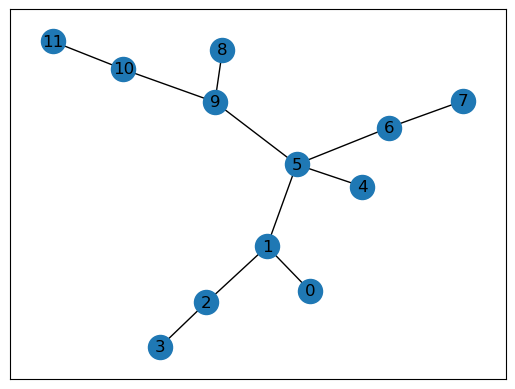

In [9]:
def test_graf(n):
    G = nx.Graph()
    for i in range (n):
        l = len(G)
        G1 = nx.path_graph([j for j in range (i * 4, (i + 1) * 4)])
        G = nx.compose(G, G1)
        if l != 0:
            G.add_edge((i - 1) * 4 + 1, i * 4 + 1)
    return G
nx.draw_networkx(test_graf(3))

In [10]:
T = test_graf(30)
rj_1 = gen_alg(T, heuristika1)
rj_2 = gen_alg(T, heuristika2)
print(rj_1, fitness(rj_1))
print(rj_2, fitness(rj_2))

[0, 3, 0, 2, 2, 0, 3, 0, 2, 0, 3, 0, 0, 3, 0, 2, 2, 0, 3, 0, 2, 0, 3, 0, 2, 0, 0, 3, 0, 3, 0, 2, 2, 0, 3, 0, 0, 3, 0, 2, 2, 0, 3, 0, 0, 3, 0, 2, 2, 0, 3, 0, 2, 0, 0, 3, 0, 3, 0, 2, 2, 0, 3, 0, 0, 3, 0, 2, 0, 3, 0, 2, 2, 0, 0, 3, 2, 0, 0, 3, 0, 3, 0, 2, 2, 0, 3, 0, 2, 0, 3, 0, 0, 3, 0, 2, 2, 0, 0, 3, 2, 0, 3, 0, 2, 0, 3, 0, 2, 0, 3, 0, 2, 0, 3, 0, 2, 0, 3, 0] 150
[2, 0, 0, 3, 0, 3, 0, 2, 2, 0, 3, 0, 0, 3, 0, 2, 2, 0, 0, 3, 2, 0, 3, 0, 2, 0, 0, 3, 0, 3, 0, 2, 2, 0, 0, 3, 2, 0, 3, 0, 0, 3, 0, 2, 0, 3, 0, 2, 2, 0, 3, 0, 0, 3, 0, 2, 2, 0, 3, 0, 2, 0, 0, 3, 0, 3, 0, 2, 2, 0, 3, 0, 0, 3, 0, 2, 2, 0, 3, 0, 2, 0, 3, 0, 0, 3, 0, 2, 2, 0, 0, 3, 2, 0, 3, 0, 0, 3, 0, 2, 2, 0, 0, 3, 0, 3, 0, 2, 2, 0, 3, 0, 0, 3, 0, 2, 2, 0, 3, 0] 150


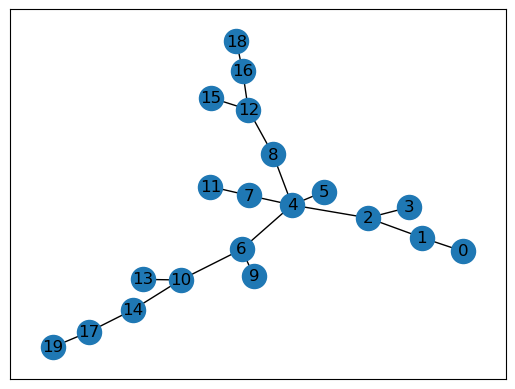

In [11]:
# promjena oznaka vrhova da svaki roditelj ima manju oznaku od svoje djece, radi lakše implementacije
T = nx.random_labeled_tree(20)

def reindex(T, root):
    D = nx.bfs_tree(T, root)
    order = list(nx.topological_sort(D))
    mapping = {v: i for i, v in enumerate(order)}

    T = nx.relabel_nodes(T, mapping)

    return T, mapping

T = reindex(T, 0)[0]
nx.draw_networkx(T)


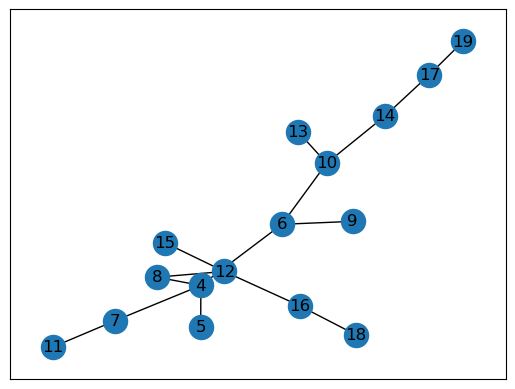

In [12]:
def roditelj(T, i):
    if i == 0:
        return None

    for j in T.neighbors(i):
        if j < i:
            return j

    raise ValueError(f"Node {i} has no parent")


def podstablo(T, w):
    T_w = T.copy()

    parent = roditelj(T, w)

    if parent is None:
        return T_w

    T_w.remove_node(parent)

    zadrzi = nx.node_connected_component(T_w, w)
    nodes_to_remove = [n for n in T_w if n not in zadrzi]
    T_w.remove_nodes_from(nodes_to_remove)

    return T_w

T_2 = podstablo(T, 4)
nx.draw_networkx(T_2)

In [13]:
import math
def DRD(T):
    T = reindex(T, min(T.nodes))[0].copy()
    L_0, L_2, L_3, L_w, L = [], [], [], [], []
    for i in range(len(T)):
        L_0.append(math.inf)
        L_2.append(2)
        L_3.append(3)
        L_w.append(math.inf)
        L.append(0)
    for i in sorted((n for n in T.nodes() if n != min(T.nodes)), reverse=True):
        j = roditelj(T, i)
        L_0[j] = min(L_0[j] + L_0[i], L_w[j] + L_2[i] - 2, L[j] + L_3[i])
        L_2[j] = L_2[j] + min(L_w[i] - 2, L_2[i], L_3[i])
        L_3[j] = L_3[j] + min(L[i], L_2[i], L_3[i])
        L_w[j] = min(L_w[j] + L_0[i], L[j] + L_2[i] + 2, L[j] + L_3[i] + 2)
        L[j] = L[j] + min(L_0[i], L_2[i], L_3[i])
    return L_0[0], L_2[0], L_3[0], L_w[0], L[0]
def minimum(vrijednosti):
    return min(vrijednosti[0], vrijednosti[1], vrijednosti[2])
print(minimum(DRD(T)))
print(fitness(gen_alg(T, heuristika1)))
print(fitness(gen_alg(T, heuristika2)))

23
23
23


3


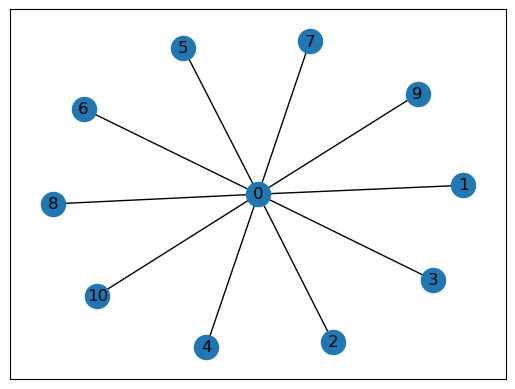

In [14]:
S = nx.star_graph(10)
nx.draw_networkx(S)
print(minimum(DRD(S)))

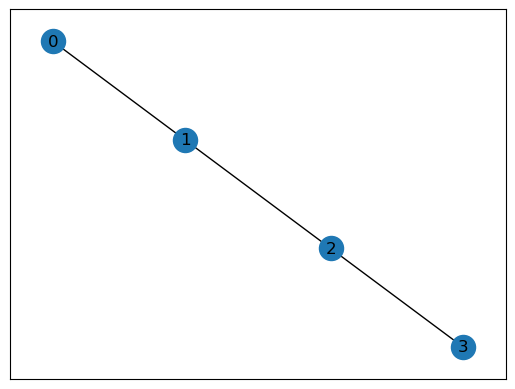

In [15]:
def razlika_stabala(T_1, T_2):
    T = T_1.copy()
    T.remove_nodes_from(T_2.nodes())
    return T
nx.draw_networkx(razlika_stabala(T, T_2))
def DRD0(T, u, v):
    put = nx.shortest_path(T, source = v, target = u) 
    T_1 = podstablo(T, put[1])
    T_0 = podstablo(T, put[0])
    T_ = razlika_stabala(T_1, T_0)

    d_00, d_01, d_02, d_03, d_04 = DRD(T_0)
    d_0, d_1, d_2, d_3, d_4 = DRD(T_)
    g00 = d_00 + d_0
    g_00 = d_00 + d_3
    g__00 = d_00 + d_4 + 3
    g02 = d_03 + d_1 - 2
    g03 = d_04 + d_2

    for i in range (2, len(put)):
        T_i = podstablo(T, put[i])
        T_ii = podstablo(T, put[i - 1])
        T_ = razlika_stabala(T_i, T_ii)
        d_0, d_1, d_2, d_3, d_4 = DRD(T_)

        a0 = min(d_0 + g00, d_3 + g02 - 2, d_4 + g03)
        a1 = min(d_3 + g00, d_4 + g02 + 2, d_4 + g03 + 2)
        a2 = d_4 + min(g00, g02, g03) + 3
        a3 = d_1 + min(g_00 - 2, g02, g03)

        g03 = d_2 + min(g__00 - 3, g02, g03)
        g00 = a0
        g_00 = a1
        g__00 = a2
        g02 = a3
    return g00, g_00, g__00, g02, g03

In [16]:
def DRD2(T, u, v):
    put = nx.shortest_path(T, source = v, target = u) 
    T_1 = podstablo(T, put[1])
    T_0 = podstablo(T, put[0])
    T_ = razlika_stabala(T_1, T_0)

    d_00, d_01, d_02, d_03, d_04 = DRD(T_0)
    d_0, d_1, d_2, d_3, d_4 = DRD(T_)
    
    g20 = d_01 + d_3 - 2
    g_20 = d_01 + d_4 + 2
    g__20 = d_01 + d_4 + 3
    g22 = d_01 + d_1
    g23 = d_01 + d_2

    k = len(put)

    for i in range (2, k):
        T_i = podstablo(T, put[i])
        T_ii = podstablo(T, put[i - 1])
        T_ = razlika_stabala(T_i, T_ii)
        d_0, d_1, d_2, d_3, d_4 = DRD(T_)

        a0 = min(d_0 + g20, d_3 + g22 - 2, d_4 + g23)
        a1 = min(d_3 + g20, d_4 + g22 + 2, d_4 + g23 + 2)
        a2 = d_4 + min(g20, g22, g23) + 3
        a3 = d_1 + min(g_20 - 2, g22, g23)

        g23 = d_2 + min(g__20 - 3, g22, g23)
        g20 = a0
        g_20 = a1
        g__20 = a2
        g22 = a3
    return g20, g_20, g__20, g22, g23

In [17]:
def DRD3(T, u, v):
    put = nx.shortest_path(T, source = v, target = u) 
    T_1 = podstablo(T, put[1])
    T_0 = podstablo(T, put[0])
    T_ = razlika_stabala(T_1, T_0)

    d_00, d_01, d_02, d_03, d_04 = DRD(T_0)
    d_0, d_1, d_2, d_3, d_4 = DRD(T_)
    g30 = d_02 + d_4
    g_30 = d_02 + d_4 + 2
    g__30 = d_02 + d_4 + 3
    g32 = d_02 + d_1
    g33 = d_02 + d_2

    k = len(put)

    for i in range (2, k):
        T_i = podstablo(T, put[i])
        T_ii = podstablo(T, put[i - 1])
        T_ = razlika_stabala(T_i, T_ii)
        d_0, d_1, d_2, d_3, d_4 = DRD(T_)

        a0 = min(d_0 + g30, d_3 + g32 - 2, d_4 + g33)
        a1 = min(d_3 + g30, d_4 + g32 + 2, d_4 + g33 + 2)
        a2 = d_4 + min(g30, g32, g33) + 3
        a3 = d_1 + min(g_30 - 2, g32, g33)

        g33 = d_2 + min(g__30 - 3, g32, g33)
        g30 = a0
        g_30 = a1
        g__30 = a2
        g32 = a3
    return g30, g_30, g__30, g32, g33

In [18]:
def DRD_U(U):
    U = U.copy()
    ciklus = nx.find_cycle(U)
    u_old, v_old = ciklus[0]

    U.remove_edge(u_old, v_old)

    U1 = U.copy()

    U, mapping = reindex(U, u_old)

    u = mapping[u_old]
    v = mapping[v_old]

    B = U.copy()

    U1, mapa = reindex(U1, v_old)
    v1 = mapa[v_old]
    u1 = mapa[u_old]

    A = U1.copy()

    
    a1 = DRD0(U, u, v)[0]
    a2 = DRD2(U, u, v)[1] - 2
    a3 = DRD2(U1, v1, u1)[1] - 2
    a4 = DRD2(U, u, v)[3]
    a5 = DRD2(U, u, v)[4]
    a6 = DRD3(U, u, v)[3]
    a7 = DRD3(U, u, v)[4]
    A.remove_node(u1)
    a8 = 0
    for c in nx.connected_components(A):
        if v1 in c:
            component = A.subgraph(c)

            a8 += DRD(component)[2]
        else:
            component = A.subgraph(c)
            a8 += minimum(DRD(component))
    B.remove_node(v)
    a9 = 0
    for c in nx.connected_components(B):
        if u in c:
            a9 += DRD(B.subgraph(c))[2]
        else:
            a9 += minimum(DRD(B.subgraph(c)))
    return min(a1, a2, a3, a4, a5, a6, a7, a8, a9) 

In [19]:
for i in range (5, 61, 5):
    C = nx.cycle_graph(i)
    print(DRD_U(C), i)
    print()

6 5

10 10

15 15

20 20

26 25

30 30

36 35

40 40

45 45

50 50

56 55

60 60



11 12 11 13 13 11 11 11 11
11


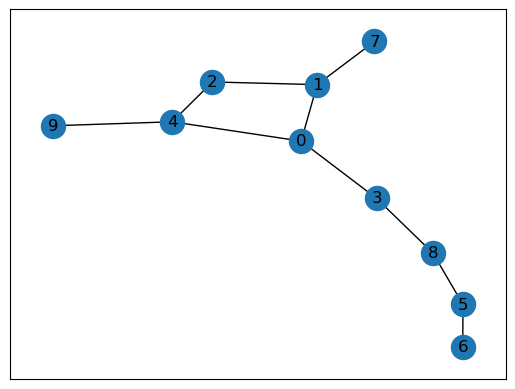

In [35]:
U = nx.random_labeled_tree(10)
u, v = random.sample(list(nx.non_edges(U)), 1)[0]
U.add_edge(u, v)
nx.draw_networkx(U)
print(DRD_U(U))

In [68]:
import time
with open("tablica1.txt", "w") as f: #testiranje puteva
    f.write(f"n & \t\g(G) & \th1 & \tt1 & \te1 & \th2 & \tt2 & \te2 & \th3 & \tt3 & \te3\n")
    for i in range(5, 101, 5):
        P = nx.path_graph(i)

        n = i
        if i % 3:
            n += 1

        start = time.perf_counter()
        n1 = fitness(gen_alg(P, heuristika1))
        t1 = time.perf_counter() - start
        e1 = (n1 - n) / n * 100

        start = time.perf_counter()
        n2 = fitness(gen_alg(P, heuristika2))
        t2 = time.perf_counter() - start
        e2 = (n2 - n) / n * 100

        start = time.perf_counter()
        n3 = fitness(gen_alg(P, heuristika3))
        t3 = time.perf_counter() - start
        e3 = (n3 - n) / n * 100

        f.write(f"{i} & \t{n} & \t{n1} & \t{t1:.2f}s & \t{e1:.2f}% & \t{n2} & \t{t2:.2f}s & \t{e2:.2f}% & \t{n3} & \t{t3:.2f}s & \t{e3:.2f}%\n")
print("Gotovo")

Gotovo


In [72]:
with open("tablica2.txt", "w") as f: #testiranje ciklusa
    f.write(f"n & \t\g(G) & \th1 & \tt1 & \te1 & \th2 & \tt2 & \te2 & \th3 & \tt3 & \te3\n")
    for i in range(5, 101, 5):
        C = nx.cycle_graph(i)
        n = i
        if i % 6 in [1, 5]:
            n += 1

        start = time.perf_counter()
        n1 = fitness(gen_alg(C, heuristika1))
        t1 = time.perf_counter() - start
        e1 = (n1 - n) / n * 100

        start = time.perf_counter()
        n2 = fitness(gen_alg(C, heuristika2))
        t2 = time.perf_counter() - start
        e2 = (n2 - n) / n * 100

        start = time.perf_counter()
        n3 = fitness(gen_alg(C, heuristika3))
        t3 = time.perf_counter() - start
        e3 = (n3 - n) / n * 100

        f.write(f"{i} & \t{n} & \t{n1} & \t{t1:.2f}s & \t{e1:.2f}% & \t{n2} & \t{t2:.2f}s & \t{e2:.2f}% & \t{n3} & \t{t3:.2f}s & \t{e3:.2f}%\n")
print("Gotovo")

Gotovo


In [37]:
def test(n): #testiranje stabala
    j = n // 25 + 2
    f = open(f"tablica{j}.txt", "w")
    greske1 = []
    greske2 = []
    greske3 = []
    vremena1 = []
    vremena2 = []
    vremena3 = []
    times2 = []
    exact = []

    f.write(f"n & \t\g(G) & \tt4 & \th1 & \tt1 & \te1 & \th2 & \tt2 & \te2 & \th3 & \tt3 & \te3\n")

    for i in range(10):

        T = nx.random_labeled_tree(n)

        start = time.perf_counter()
        x1 = fitness(gen_alg(T, heuristika1))
        t1 = time.perf_counter() - start

        start = time.perf_counter()
        x2 = fitness(gen_alg(T, heuristika2))
        t2 = time.perf_counter() - start

        start = time.perf_counter()
        x3 = fitness(gen_alg(T, heuristika3))
        t3 = time.perf_counter() - start

        start = time.perf_counter()
        x4 = minimum(DRD(T))
        t4 = time.perf_counter() - start

        e1 = (x1 - x4) / x4 * 100
        e2 = (x2 - x4) / x4 * 100
        e3 = (x3 - x4) / x4 * 100
        

        greske1.append(e1)
        greske2.append(e2)
        greske3.append(e3)
        vremena1.append(t1)
        vremena2.append(t2)
        vremena3.append(t3)

        exact.append(t4)

        f.write(f"{n} & \t{x4} & \t{t4:.5f} & \t{x1} & \t{t1:.2f}s & \t{e1:.2f}% & \t{x2} & \t{t2:.2f}s & \t{e2:.2f}% & \t{x3} & \t{t3:.2f}s & \t{e3:.2f}%\n")

    f.write(f"GA1: prosjecna greška = {sum(greske1)/len(greske1):.2f}%, "
          f"prosjecno vrijeme = {sum(vremena1)/len(vremena1):.2f}s\n")

    f.write(f"GA2: prosjecna greška = {sum(greske2)/len(greske2):.2f}%, "
          f"prosjecno vrijeme = {sum(vremena2)/len(vremena2):.2f}s\n")
    f.write(f"GA3: prosjecna greška = {sum(greske3)/len(greske3):.2f}%, "
          f"prosjecno vrijeme = {sum(vremena3)/len(vremena3):.2f}s\n")

    f.write(f"Egzaktni algoritam: prosjecno vrijeme = {sum(exact) / len(exact):.5f}s\n")
    f.close()
    print("Gotovo")

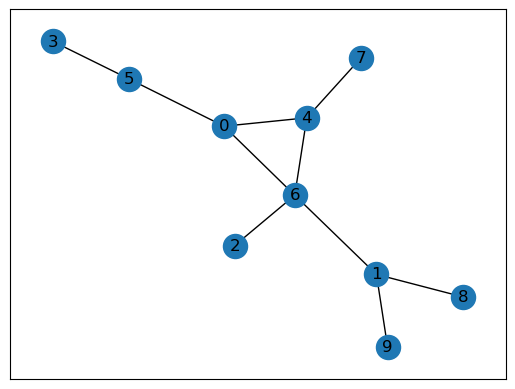

In [120]:
def jednociklicni(T):
    u, v = random.sample(list(nx.non_edges(T)), 1)[0]
    T.add_edge(u, v)
T = nx.random_labeled_tree(10)
jednociklicni(T)
nx.draw_networkx(T)

In [130]:
def test2(n): #testiranje jednocikličnih grafova
    j = n // 25 + 6
    f = open(f"tablica{j}.txt", "w")
    greske1 = []
    greske2 = []
    greske3 = []
    vremena1 = []
    vremena2 = []
    vremena3 = []
    times2 = []
    exact = []

    f.write(f"n & \t\g(G) & \tt4 & \th1 & \tt1 & \te1 & \th2 & \tt2 & \te2 & \th3 & \tt3 & \te3 & \n")

    for i in range(10):

        T = nx.random_labeled_tree(n)
        jednociklicni(T)

        start = time.perf_counter()
        x1 = fitness(gen_alg(T, heuristika1))
        t1 = time.perf_counter() - start

        start = time.perf_counter()
        x2 = fitness(gen_alg(T, heuristika2))
        t2 = time.perf_counter() - start

        start = time.perf_counter()
        x3 = fitness(gen_alg(T, heuristika3))
        t3 = time.perf_counter() - start

        start = time.perf_counter()
        x4 = DRD_U(T)
        t4 = time.perf_counter() - start

        e1 = (x1 - x4) / x4 * 100
        e2 = (x2 - x4) / x4 * 100
        e3 = (x3 - x4) / x4 * 100
        

        greske1.append(e1)
        greske2.append(e2)
        greske3.append(e3)
        vremena1.append(t1)
        vremena2.append(t2)
        vremena3.append(t3)

        exact.append(t4)

        f.write(f"{n} & \t{x4} & \t{t4:.5f} & \t{x1} & \t{t1:.2f}s & \t{e1:.2f}% & \t{x2} & \t{t2:.2f}s & \t{e2:.2f}% & \t{x3} & \t{t3:.2f}s & \t{e3:.2f}%\n")


    f.write(f"GA1: prosjecna greška = {sum(greske1)/len(greske1):.2f}%, "
          f"prosjecno vrijeme = {sum(vremena1)/len(vremena1):.2f}s\n")

    f.write(f"GA2: prosjecna greška = {sum(greske2)/len(greske2):.2f}%, "
          f"prosjecno vrijeme = {sum(vremena2)/len(vremena2):.2f}s\n")
    f.write(f"GA3: prosjecna greška = {sum(greske3)/len(greske3):.2f}%, "
          f"prosjecno vrijeme = {sum(vremena3)/len(vremena3):.2f}s\n")

    f.write(f"Egzaktni algoritam: prosjecno vrijeme = {sum(exact) / len(exact):.5f}s\n")
    f.close()
    print("Gotovo")

In [39]:
import time

def random_graph():
    G = nx.gnp_random_graph(100, 0.05)

    while nx.number_connected_components(G) not in (1, 2):
        G = nx.gnp_random_graph(100, 0.05)

    return G

with open("tablica11.txt", "w") as f: #testiranje nasumicnih grafova
    f.write(f"n & \th1 & \tt1 & \th2 & \tt2 & \th3 & \tt3 \\\n \hline\n")
    for i in range(20):
        G = random_graph()

        start = time.perf_counter()
        n1 = fitness(gen_alg(G, heuristika1))
        t1 = time.perf_counter() - start

        start = time.perf_counter()
        n2 = fitness(gen_alg(G, heuristika2))
        t2 = time.perf_counter() - start

        start = time.perf_counter()
        n3 = fitness(gen_alg(G, heuristika3))
        t3 = time.perf_counter() - start

        f.write(f"100 & \t{n1} & \t{t1:.2f}s & \t{n2} & \t{t2:.2f}s & \t{n3} & \t{t3:.2f}s \\ \n")
print("Gotovo")

Gotovo
